<a href="https://colab.research.google.com/github/giannismantzaris-cmd/DAMA61/blob/main/Mantzaris%20-%20DAMA61_final2026_problem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 style="text-align:center;"> HELLENIC OPEN UNIVERSITY - SCHOOL OF SCIENCE AND TECHNOLOGY</h2>
<h2 style="text-align:center;"> DATA SCIENCE AND MACHINE LEARNING : DAMA61 ACAD. YEAR 2025-26</h2>
<h3 style="text-align:center;"> FINAL EXAM PROBLEM 1</h3>
<hr>

## Problem 1

Work with the **California Housing dataset** included in the Scikit-Learn library to build and evaluate regression pipelines. The task is to predict the median house value of California districts using demographic and geographic features. Set `random_state = 42` whenever necessary, and present your results clearly and concisely.

1) Use the **`fetch_california_housing`** function to import the corresponding data. Convert the dataset into a Pandas DataFrame, including all feature columns and appending the target variable as the final column. Display the first few rows of the dataset and report the number of observations and features. **[10%]**

2) Select the target variable, **`MedHouseVal`**, and visualize its distribution using a histogram with 30 bins. Additionally, create a scatter plot between **`MedInc`** and **`MedHouseVal`**. Briefly comment on the shape of the target distribution and the apparent relationship between median income and house value. **[10%]**

3) Split the data into training and test sets using a 75/25 split with **`random_state = 42`**. Build a **Voting ensemble** that combines three **Linear Support Vector Regressors** with a regularization parameter C = 0.01, 0.1 and 1, respectively. For each Linear SVR model, create a Scikit-learn pipeline to standardize the data before training. Use appropriate settings to ensure convergence where needed. **[30%]**

4) Build a **Bagging ensemble of Decision Tree regressors**, using **`BaggingRegressor`** with a decision tree as the base estimator. Perform a 5-fold cross-validation grid search of hyperparameter tuning to optimize the Bagging Decision Tree Regressor, using the following grid:

   - **`estimator__max_depth`**: `[None, 5]`
   - **`n_estimators`**: `[25, 50]`
   - **`max_samples`**: `[0.5, 0.75]`
   - **`max_features`**: `[0.5, 0.75]`

   Use the **negative mean absolute error** as the scoring function. Report the best parameters and the best cross-validation MAE. Fit the Bagging Decision Tree Regressor (with best parameters) to the training data. **[35%]**

5) Present the test-set performance of the best Linear SVR ensemble and the best Bagging Decision Tree Regressor using the following metrics:

   - **Mean Absolute Error, MAE**
   - **Root Mean Squared Error, RMSE**
   - **Coefficient of determination, R²**

   Also, plot the predicted versus actual values for each model. Comment on which model appears to fit the test data better. **[15%]**

In [1]:
# increase the width of the notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [2]:
# helpful imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from sklearn.ensemble import VotingRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [4]:
# import the data and convert to data frame
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [5]:
# Display the first few rows of the dataset
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
# report the number of observaEons and features.
print("Dataset shape:", df.shape)
print("Number of observations:", df.shape[0])
print("Number of features:", len(housing.feature_names))

Dataset shape: (20640, 9)
Number of observations: 20640
Number of features: 8


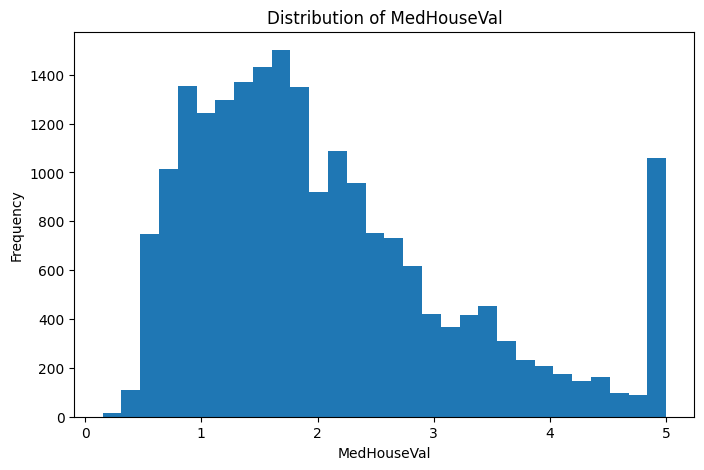

In [8]:
# plot histogram for Med house value
plt.figure(figsize=(8, 5))
plt.hist(df["MedHouseVal"], bins=30)
plt.xlabel("MedHouseVal")
plt.ylabel("Frequency")
plt.title("Distribution of MedHouseVal")
plt.show()

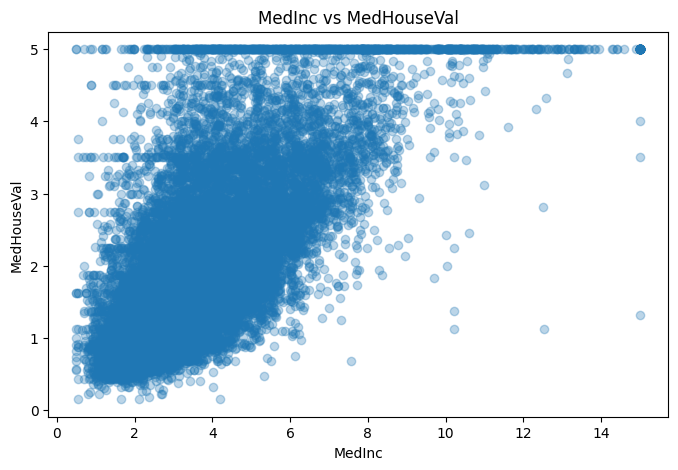

In [9]:
# create a scaOer plot between MedInc and MedHouseVal.
plt.figure(figsize=(8, 5))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.3)
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title("MedInc vs MedHouseVal")
plt.show()

The distribution of MedHouseVal is right skewed with most observations  concentrated between 1 and 3, while fewer observations have very high values.

The scatter plot shows a clear positive relationship between median income and median house value. This is ex[ected as areas with higher median income tend to have higher house values. However, we still notice some variability in the data.

In [10]:
# Feature - target separation
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# Train/test split (75/25)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [11]:
# print training and test sets
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (15480, 8)
X_test: (5160, 8)
y_train: (15480,)
y_test: (5160,)


In [12]:
# build 3 linear SVR pipelines with scalling and a voting ensemble that combines them
SVR1 = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", LinearSVR(C=0.01, max_iter=20000, random_state=42))
])

SVR2 = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", LinearSVR(C=0.1, max_iter=20000, random_state=42))
])

SVR3 = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", LinearSVR(C=1, max_iter=20000, random_state=42))
])

voting_svr = VotingRegressor([
    ("SVR1", SVR1),
    ("SVR2", SVR2),
    ("SVR3", SVR3)
])

voting_svr.fit(X_train, y_train)

VotingRegressor(estimators=[('SVR1',
                             Pipeline(steps=[('scaler', StandardScaler()),
                                             ('svr',
                                              LinearSVR(C=0.01, max_iter=20000,
                                                        random_state=42))])),
                            ('SVR2',
                             Pipeline(steps=[('scaler', StandardScaler()),
                                             ('svr',
                                              LinearSVR(C=0.1, max_iter=20000,
                                                        random_state=42))])),
                            ('SVR3',
                             Pipeline(steps=[('scaler', StandardScaler()),
                                             ('svr',
                                              LinearSVR(C=1, max_iter=20000,
                                                        random_state=42))]))])

In [13]:
# Perform a 5-fold cross-validaEon grid search of hyperparameter tuning
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    random_state=42
)

param_grid = {
    "estimator__max_depth": [None, 5],
    "n_estimators": [25, 50],
    "max_samples": [0.5, 0.75],
    "max_features": [0.5, 0.75]
}

grid_search = GridSearchCV(bag_reg, param_grid, cv=5, scoring="neg_mean_absolute_error")

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

Best parameters:
{'estimator__max_depth': None, 'max_features': 0.75, 'max_samples': 0.75, 'n_estimators': 25}

Best CV MAE:
0.3331747020413436


In [14]:
# fit the best model
best_bagging_reg = grid_search.best_estimator_
best_bagging_reg.fit(X_train, y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42),
                 max_features=0.75, max_samples=0.75, n_estimators=25,
                 random_state=42)

The best Bagging Decision Tree Regressor uses 25 decision trees with no max depth. Each tree is trained using 75% of the training samples and 75% of the available features. The best 5-fold cross-validation MAE is 0.333, which indicates that the tuned Bagging Regressor achieves relatively good  performance

In [16]:
# present the test set performance of each model

y_pred_svr = voting_svr.predict(X_test)
y_pred_bagging = best_bagging_reg.predict(X_test)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

mae_bagging = mean_absolute_error(y_test, y_pred_bagging)
rmse_bagging = np.sqrt(mean_squared_error(y_test, y_pred_bagging))
r2_bagging = r2_score(y_test, y_pred_bagging)

In [17]:
print("Voting Linear SVR Ensemble")
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R2:", r2_svr)

Voting Linear SVR Ensemble
MAE: 0.5105581746963546
RMSE: 0.7554490942834199
R2: 0.5687004795848738


In [18]:
print("Bagging Decision Tree Regressor")
print("MAE:", mae_bagging)
print("RMSE:", rmse_bagging)
print("R2:", r2_bagging)

Bagging Decision Tree Regressor
MAE: 0.3221877348062015
RMSE: 0.4823265123439907
R2: 0.8241870605865138


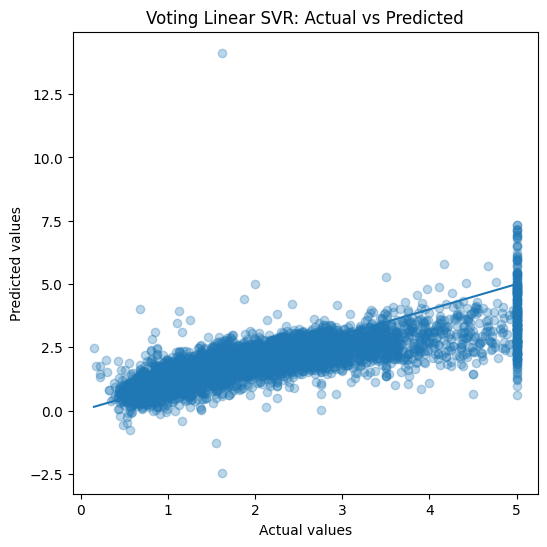

In [19]:
# predicted vs actual plot for voting linear SVR

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Voting Linear SVR: Actual vs Predicted")
plt.show()

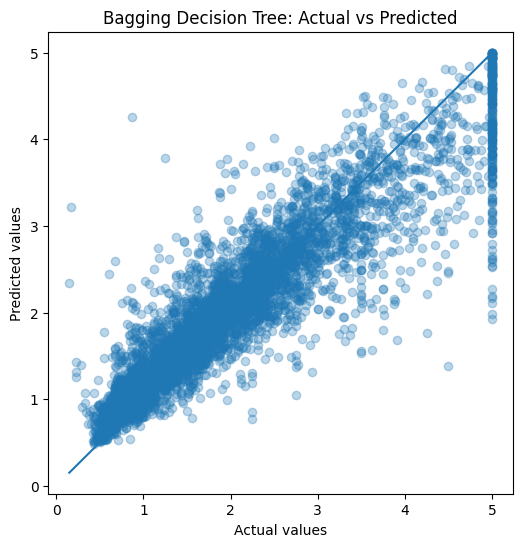

In [20]:
# predicted vs actual plot for bagging decision tree

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_bagging, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Bagging Decision Tree: Actual vs Predicted")
plt.show()

Both from the metrics and the plots, it is very clear that the Bagging decision tree regressor performs clearly better than the Voting Linear SVR ensemble on the test set. It achieves lower MAE (0.322 vs 0.511) and RMSE (0.482 vs 0.755), indicating smaller prediction errors. Also a substantially higher R2 score (0.824 vs 0.569), meaning that it explains a much larger proportion of the variance in the target variable. This can be explained byt the fact that the decision tree can capture nonlinear relationships that exist in the dataset, while the linear SVR ensemble fails to do so.